In [1]:
%matplotlib widget
import scipp as sc
from drcspec.instrument import Instrument
from drcspec.components.source import Source
import matplotlib.pyplot as plt

T_OFFSET = sc.scalar(1.7, unit="ms")
central_wavelength = sc.scalar(3.0, unit="Å")
f_M = sc.scalar(224, unit="Hz")
n: int = 2
phase_bw3 = sc.scalar(0.0, unit="deg")

cspec = Instrument(central_wavelength, f_M, n, phase_bw3, t_offset=T_OFFSET)
cspec.source = Source(facility="ess-cspec", neutrons=5_000_000, pulses=1)  # type: ignore
print(cspec)
res = cspec.run()

CSPEC running with cententral wavelength = 3.00 Å
PSC frequency =  112.0 Hz, RRM frequency = 112.0 Hz, MC frequency = 224 Hz


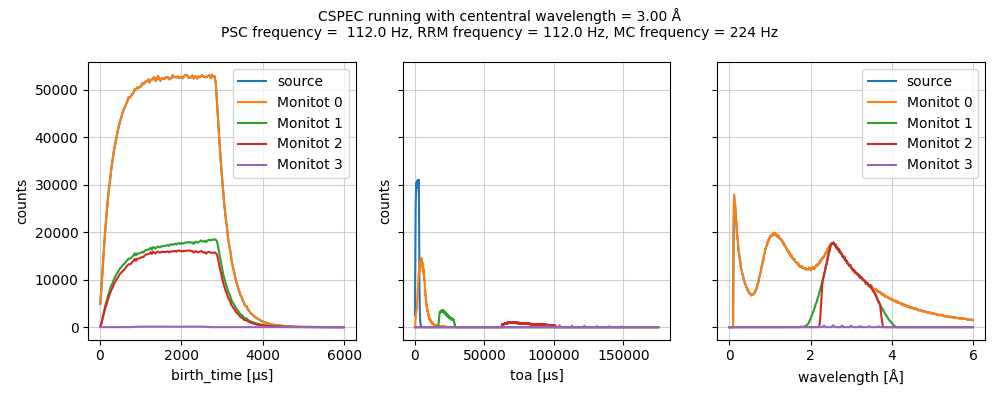

In [10]:
fig, axes = plt.subplots(ncols=3, sharey=True, figsize=(10, 4))


source_data = cspec.source.data["pulse", 0]

# ---------------- birth time -------------------------
ax = axes[0]
birth_time_range = sc.linspace("birth_time", 0, 6000, num=200, unit="us")
source_data_hist_t = source_data.hist(birth_time=birth_time_range)
x_to_plot = sc.midpoints(source_data_hist_t.coords["birth_time"])
ax.plot(x_to_plot, source_data_hist_t, label="source")

for i in range(4):
    data = (
        res.detectors[f"Monitor {i}"].data["pulse", 0].hist(birth_time=birth_time_range)
    )
    ax.plot(sc.midpoints(data.coords["birth_time"]), data, label=f"Monitot {i}")

ax.grid(alpha=0.6)
ax.set_ylabel(source_data_hist_t.unit)
ax.set_xlabel(
    source_data_hist_t.dim
    + f" [{source_data_hist_t.coords[source_data_hist_t.dim].unit}]"
)
ax.legend()
# ---------------- time of arrival -------------------------
ax = axes[1]
toa_range = sc.linspace("toa", 0, 175_000, num=10_000, unit="us")
source_data_hist_t = source_data.hist(toa=toa_range)
x_to_plot = sc.midpoints(source_data_hist_t.coords["toa"])
ax.plot(x_to_plot, source_data_hist_t, label="source")

for i in range(4):
    data = res.detectors[f"Monitor {i}"].data["pulse", 0].hist(toa=toa_range)
    ax.plot(sc.midpoints(data.coords["toa"]), data, label=f"Monitot {i}")

ax.grid(alpha=0.6)
ax.set_ylabel(source_data_hist_t.unit)
ax.set_xlabel(
    source_data_hist_t.dim
    + f" [{source_data_hist_t.coords[source_data_hist_t.dim].unit}]"
)

# ---------------- wavelength -------------------------
ax = axes[2]
wavelength_range = sc.linspace("wavelength", 0, 6, num=500, unit="Å")
source_data_hist_l = source_data.hist(wavelength=wavelength_range)
x_to_plot = sc.midpoints(source_data_hist_l.coords["wavelength"])
ax.plot(x_to_plot, source_data_hist_l, label="source")
for i in range(4):
    data = (
        res.detectors[f"Monitor {i}"].data["pulse", 0].hist(wavelength=wavelength_range)
    )
    ax.plot(sc.midpoints(data.coords["wavelength"]), data, label=f"Monitot {i}")

ax.grid(alpha=0.6)
ax.set_xlabel(
    source_data_hist_l.dim
    + f" [{source_data_hist_l.coords[source_data_hist_l.dim].unit}]"
)


ax.legend()
fig.suptitle(str(cspec), fontsize=10)
plt.tight_layout()